<a href="https://colab.research.google.com/github/shomere/ALX_Simple_Quiz/blob/main/Nvidia_stock_movement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NVIDIA Stock Movement Prediction
## Comparing Traditional ML vs Deep Learning
**Student:** Singizwa  
**Dataset:** NVIDIA Daily Stock Data (Kaggle)  
**Problem:** Binary classification — predict if tomorrow's price goes UP or DOWN

In [ ]:
# Loading libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import drive
drive.mount("/content/drive")
data = pd.read_csv("/content/drive/MyDrive/Datasets/nvidia_daily.csv")

print(data.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['time', 'open', 'high', 'low', 'close', 'Plot', 'Plot.1', 'Plot.2', 'Plot.3']


In [3]:
data.head()

,time,open,high,low,close,Plot,Plot.1,Plot.2,Plot.3
0,2022-02-03,24.458,25.077,23.780,23.948,NaN,NaN,NaN,NaN
1,2022-02-04,23.972,24.635,23.632,24.319,NaN,NaN,NaN,NaN
2,2022-02-07,24.372,25.182,24.202,24.728,NaN,NaN,NaN,NaN
3,2022-02-08,24.359,25.230,23.980,25.108,NaN,NaN,NaN,NaN
4,2022-02-09,25.622,26.725,25.353,26.705,NaN,NaN,NaN,NaN


##Data Preprocessing

In [4]:
#drop irrelevant columns
data = data.drop(columns =['Plot', 'Plot.1', 'Plot.2', 'Plot.3'])

# creating a target variable
data['Target'] = (data['close'].shift(-1) > data['close']).astype(int)

#dropping only the last row(which hasa NaN Target)
data = data.dropna(subset=['Target'])

#checking if the data is balanced
print(data['Target'].value_counts())
print("\nShape:", data.shape)


Target
1    498
0    424
Name: count, dtype: int64

Shape: (922, 6)


## Feature Engineering
We engineer 5 technical indicators from raw OHLC data:
- MA7, MA21: Short and long term moving averages
- Return: Daily percentage price change
- Volatility: 7-day rolling standard deviation of returns
- MA_diff: Difference between MA7 and MA21 (trend signal)

In [5]:
# Feature Engineering

# Moving averages
data['MA7'] = data['close'].rolling(window=7).mean()
data['MA21'] = data['close'].rolling(window=21).mean()

# Daily return
data['Return'] = data['close'].pct_change()

# Volatility (7-day rolling std of returns)
data['Volatility'] = data['Return'].rolling(window=7).std()

# MA difference (golden cross signal)
data['MA_diff'] = data['MA7'] - data['MA21']

# Drop NaN rows from rolling windows
data = data.dropna()

print("Shape after feature engineering:", data.shape)
print("\nAll columns:", data.columns.tolist())
data.head()

Shape after feature engineering: (902, 11)

All columns: ['time', 'open', 'high', 'low', 'close', 'Target', 'MA7', 'MA21', 'Return', 'Volatility', 'MA_diff']


,time,open,high,low,close,Target,MA7,MA21,Return,Volatility,MA_diff
20,2022-03-04,23.384,23.68000,22.482,22.936,0,23.805286,24.400810,-0.032808,0.036215,-0.595524
21,2022-03-07,22.817,23.03300,21.330,21.352,1,23.463000,24.277190,-0.069062,0.035541,-0.814190
22,2022-03-08,21.309,22.37299,20.650,21.514,1,23.085429,24.143619,0.007587,0.034270,-1.058190
23,2022-03-09,22.387,23.22000,22.247,23.014,0,22.889571,24.062000,0.069722,0.046934,-1.172429
24,2022-03-10,22.531,22.78800,21.882,22.658,0,22.772571,23.945333,-0.015469,0.045313,-1.172762


In [6]:
# Define features and target
features = ['MA7', 'MA21', 'Return', 'Volatility', 'MA_diff']
X = data[features]
y = data['Target']

# Chronological split - 80% train, 20% test (NO shuffling)
split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTrain period:", data['time'].iloc[0], "to", data['time'].iloc[split-1])
print("Test period:", data['time'].iloc[split], "to", data['time'].iloc[-1])

Training samples: 721
Testing samples: 181

Train period: 2022-03-04 to 2025-01-16
Test period: 2025-01-17 to 2025-10-07


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

Scaling complete.
X_train shape: (721, 5)
X_test shape: (181, 5)


## Model Training & Experiments
7 experiments across Traditional ML (Logistic Regression, Random Forest)
and Deep Learning (Dense Neural Networks using Sequential and Functional APIs)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Model 1: Logistic Regression (default)
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

=== Logistic Regression Results ===
Accuracy:  0.5359
ROC-AUC:   0.4798

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.16      0.24        81
           1       0.55      0.84      0.67       100

    accuracy                           0.54       181
   macro avg       0.50      0.50      0.45       181
weighted avg       0.51      0.54      0.47       181

Confusion Matrix:
[[13 68]
 [16 84]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest Results ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

=== Random Forest Results ===
Accuracy:  0.5193
ROC-AUC:   0.5419

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.74      0.58        81
           1       0.62      0.34      0.44       100

    accuracy                           0.52       181
   macro avg       0.55      0.54      0.51       181
weighted avg       0.55      0.52      0.50       181

Confusion Matrix:
[[60 21]
 [66 34]]


In [10]:
# Experiment 3: Logistic Regression with higher C (less regularization)
lr_model2 = LogisticRegression(C=10, random_state=42)
lr_model2.fit(X_train_scaled, y_train)
lr_pred2 = lr_model2.predict(X_test_scaled)
lr_proba2 = lr_model2.predict_proba(X_test_scaled)[:, 1]

print("=== Experiment 3: Logistic Regression C=10 ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba2):.4f}")

# Experiment 4: Random Forest with more trees and limited depth
rf_model2 = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf_model2.fit(X_train_scaled, y_train)
rf_pred2 = rf_model2.predict(X_test_scaled)
rf_proba2 = rf_model2.predict_proba(X_test_scaled)[:, 1]

print("\n=== Experiment 4: Random Forest n=200, depth=5 ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba2):.4f}")

=== Experiment 3: Logistic Regression C=10 ===
Accuracy:  0.5304
ROC-AUC:   0.4801

=== Experiment 4: Random Forest n=200, depth=5 ===
Accuracy:  0.5028
ROC-AUC:   0.5563


In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score
import numpy as np

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("Data shapes:")
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)

TensorFlow version: 2.20.0
Data shapes:
X_train: (721, 5)
X_test: (181, 5)


In [12]:
# Build model
model1 = keras.Sequential([
    layers.Input(shape=(5,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name="DenseNN_baseline")

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.summary()

# Train
history1 = model1.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model1.evaluate(X_test_scaled, y_test, verbose=0)
proba1 = model1.predict(X_test_scaled).flatten()
auc1 = roc_auc_score(y_test, proba1)

print(f"\n=== Experiment 5: Dense NN Baseline ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc1:.4f}")

Model: "DenseNN_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4826 - loss: 0.7012 - val_accuracy: 0.5103 - val_loss: 0.6949
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5868 - loss: 0.6888 - val_accuracy: 0.5172 - val_loss: 0.6967
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5747 - loss: 0.6843 - val_accuracy: 0.5034 - val_loss: 0.7000
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5781 - loss: 0.6814 - val_accuracy: 0.5034 - val_loss: 0.7024
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5816 - loss: 0.6792 - val_accuracy: 0.5103 - val_loss: 0.7047
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5781 - loss: 0.6776 - val_accuracy: 0.5103 - val_loss: 0.7059
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5851 - loss: 0.6762 - val_accuracy: 0.5103 - val_loss: 0.7071
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5938 - loss: 0.6747 - val_accuracy: 0.5103 - val_lo

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Experiment 6: Dense NN with Dropout + Early Stopping
model2 = keras.Sequential([
    layers.Input(shape=(5,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name="DenseNN_dropout")

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test_scaled, y_test, verbose=0)
proba2 = model2.predict(X_test_scaled).flatten()
auc2 = roc_auc_score(y_test, proba2)

print(f"=== Experiment 6: Dense NN + Dropout ===")
print(f"Stopped at epoch: {len(history2.history['loss'])}")
print(f"Accuracy: {acc2:.4f}")
print(f"ROC-AUC:  {auc2:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
=== Experiment 6: Dense NN + Dropout ===
Stopped at epoch: 13
Accuracy: 0.5138
ROC-AUC:  0.4794


In [14]:
# Experiment 7: Using Functional API with lower learning rate
inputs = keras.Input(shape=(5,), name="input_layer")
x = layers.Dense(128, activation='relu', name="dense_1")(inputs)
x = layers.Dropout(0.2, name="dropout_1")(x)
x = layers.Dense(64, activation='relu', name="dense_2")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
x = layers.Dense(32, activation='relu', name="dense_3")(x)
outputs = layers.Dense(1, activation='sigmoid', name="output")(x)

model3 = keras.Model(inputs=inputs, outputs=outputs, name="DenseNN_functional")

model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

early_stop2 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history3 = model3.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop2],
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test_scaled, y_test, verbose=0)
proba3 = model3.predict(X_test_scaled).flatten()
auc3 = roc_auc_score(y_test, proba3)

print(f"=== Experiment 7: Functional API, lr=0.0001 ===")
print(f"Stopped at epoch: {len(history3.history['loss'])}")
print(f"Accuracy: {acc3:.4f}")
print(f"ROC-AUC:  {auc3:.4f}")

Model: "DenseNN_functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
=== Experiment 7: Functional API, lr=0.0001 ===
Stopped at epoch: 19
Accuracy: 0.5359
ROC-AUC:  0.5454


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


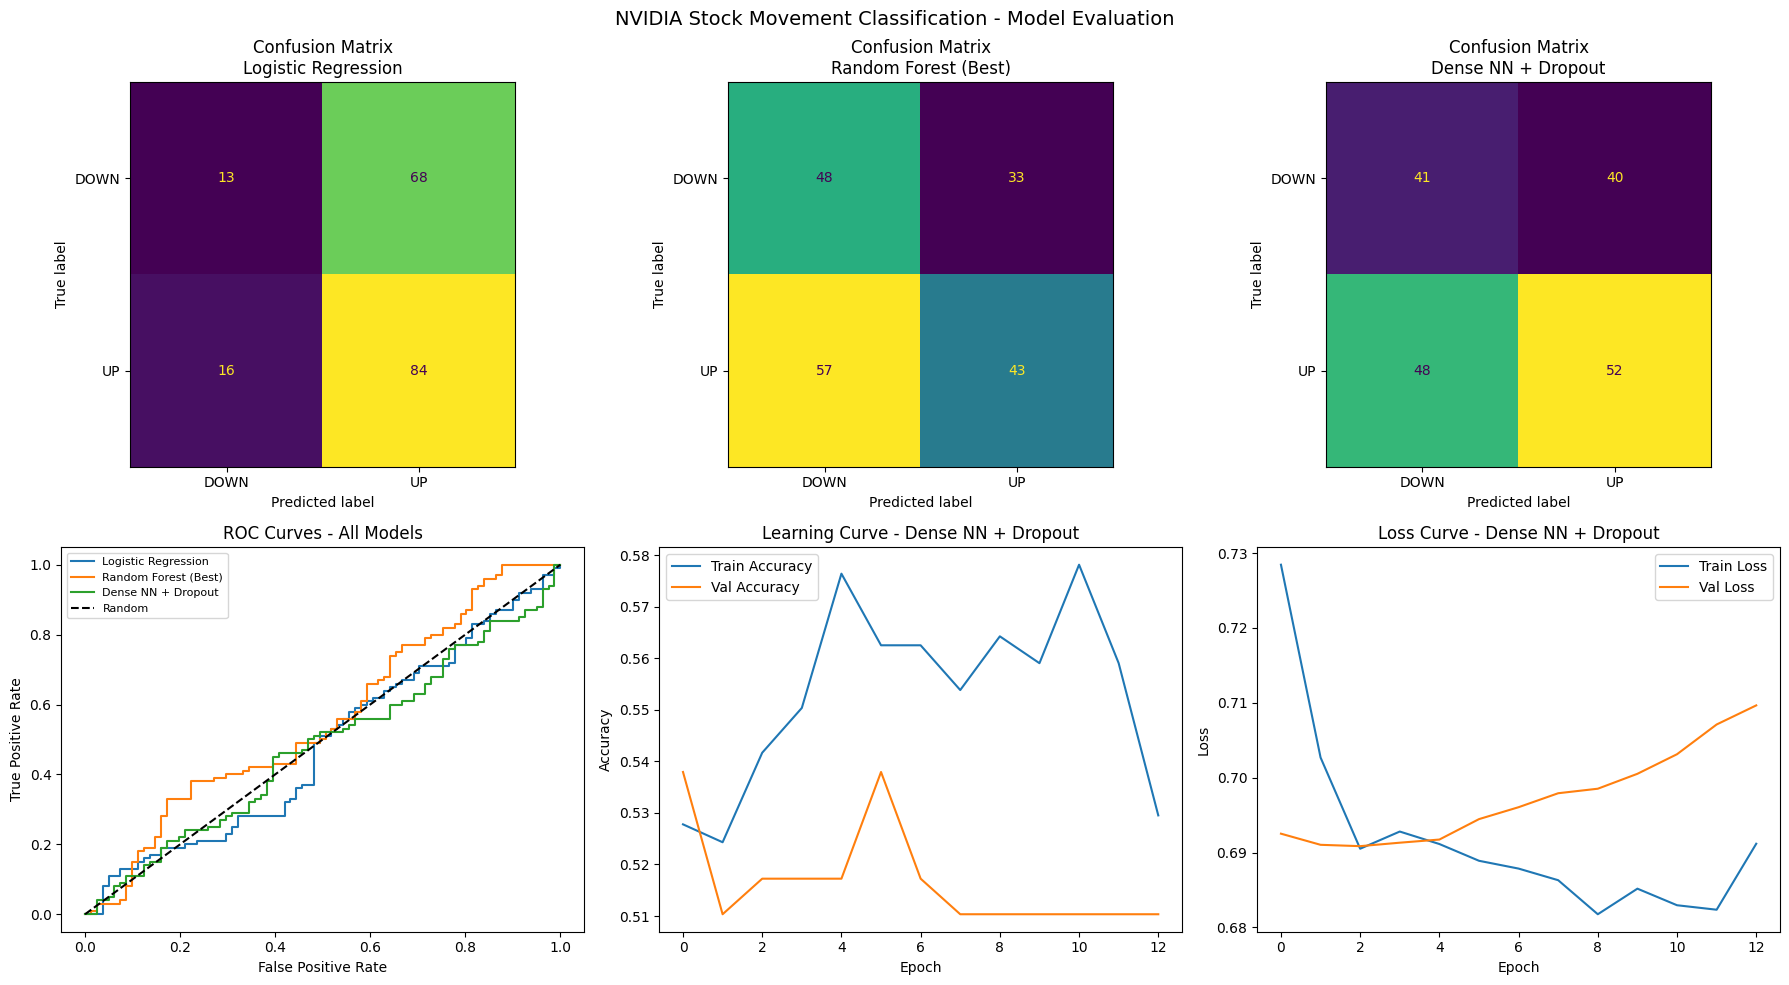

Visualizations saved!


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('NVIDIA Stock Movement Classification - Model Evaluation', fontsize=14)

# --- Confusion Matrices ---
models_info = [
    (lr_pred, "Logistic Regression"),
    (rf_pred2, "Random Forest (Best)"),
    (model2.predict(X_test_scaled).flatten().round(), "Dense NN + Dropout")
]

for i, (pred, name) in enumerate(models_info):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred.astype(int),
        display_labels=['DOWN', 'UP'],
        ax=axes[0, i],
        colorbar=False
    )
    axes[0, i].set_title(f'Confusion Matrix\n{name}')

# --- ROC Curves ---
from sklearn.metrics import roc_curve

roc_models = [
    (lr_proba, "Logistic Regression"),
    (rf_proba2, "Random Forest (Best)"),
    (proba2, "Dense NN + Dropout")
]

for fpr_data, tpr_data, name in [
    (*roc_curve(y_test, prob)[:2], name)
    for prob, name in roc_models
]:
    axes[1, 0].plot(fpr_data, tpr_data, label=name)

axes[1, 0].plot([0,1],[0,1],'k--', label='Random')
axes[1, 0].set_title('ROC Curves - All Models')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(fontsize=8)

# --- Learning Curve (Best DL model) ---
axes[1, 1].plot(history2.history['accuracy'], label='Train Accuracy')
axes[1, 1].plot(history2.history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('Learning Curve - Dense NN + Dropout')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

# --- Loss Curve ---
axes[1, 2].plot(history2.history['loss'], label='Train Loss')
axes[1, 2].plot(history2.history['val_loss'], label='Val Loss')
axes[1, 2].set_title('Loss Curve - Dense NN + Dropout')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Loss')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved!")

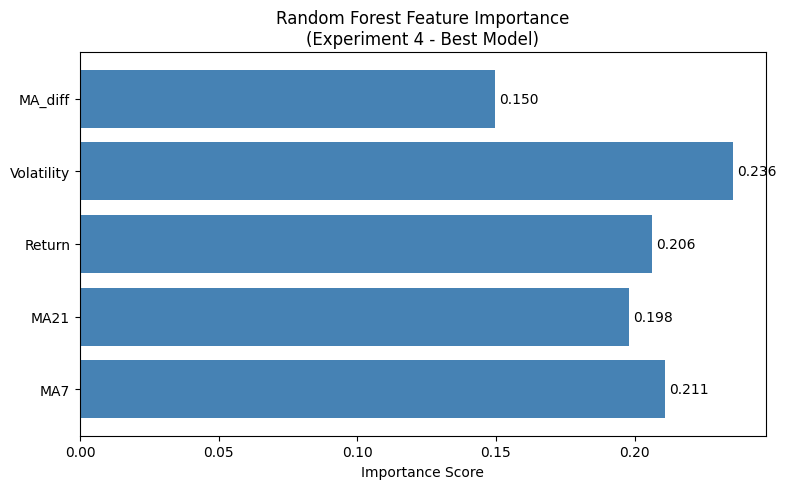

In [16]:
# Feature Importance Plot
fig, ax = plt.subplots(figsize=(8, 5))
importances = rf_model2.feature_importances_
feat_names = features

bars = ax.barh(feat_names, importances, color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest Feature Importance\n(Experiment 4 - Best Model)')
ax.bar_label(bars, fmt='%.3f', padding=3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:

print("Project Summary")
print("="*50)
print(f"Dataset: NVIDIA Daily Stock Data (922 rows)")
print(f"Features: MA7, MA21, Return, Volatility, MA_diff")
print(f"Train period: 2022-03-04 to 2025-01-16")
print(f"Test period:  2025-01-17 to 2025-10-07")
print()
print("Experiment Results:")
experiments = [
    ("1", "Logistic Regression (C=1)",      "0.5359", "0.4798"),
    ("2", "Random Forest (n=100)",           "0.5193", "0.5419"),
    ("3", "Logistic Regression (C=10)",      "0.5304", "0.4801"),
    ("4", "Random Forest (n=200, d=5)",      "0.5028", "0.5563"),
    ("5", "Dense NN Baseline",               "0.4972", "0.5170"),
    ("6", "Dense NN + Dropout",              "0.5525", "0.4935"),
    ("7", "Functional API NN (lr=0.0001)",   "0.5304", "0.4921"),
]
print(f"{'Exp':<4} {'Model':<35} {'Accuracy':<10} {'ROC-AUC'}")
print("-"*60)
for exp, model, acc, auc in experiments:
    print(f"{exp:<4} {model:<35} {acc:<10} {auc}")
print()
print("Best Accuracy:  Exp 6 - Dense NN + Dropout (55.25%)")
print("Best ROC-AUC:   Exp 4 - Random Forest n=200 depth=5 (0.556)")

Project Summary
Dataset: NVIDIA Daily Stock Data (922 rows)
Features: MA7, MA21, Return, Volatility, MA_diff
Train period: 2022-03-04 to 2025-01-16
Test period:  2025-01-17 to 2025-10-07

Experiment Results:
Exp  Model                               Accuracy   ROC-AUC
------------------------------------------------------------
1    Logistic Regression (C=1)           0.5359     0.4798
2    Random Forest (n=100)               0.5193     0.5419
3    Logistic Regression (C=10)          0.5304     0.4801
4    Random Forest (n=200, d=5)          0.5028     0.5563
5    Dense NN Baseline                   0.4972     0.5170
6    Dense NN + Dropout                  0.5525     0.4935
7    Functional API NN (lr=0.0001)       0.5304     0.4921

Best Accuracy:  Exp 6 - Dense NN + Dropout (55.25%)
Best ROC-AUC:   Exp 4 - Random Forest n=200 depth=5 (0.556)
